# Time dynamics: JAX prototype vs original numba LCODE

This notebook benchmarks the **differentiable JAX time loop** (branch `jax-2d-prototype`)
against the **original numba LCODE** on a self-consistent, time-dependent run: an identical
driver bunch is initialised in both, evolved for several time steps, and their outputs are
compared.

The JAX time step is the quasistatic loop **deposit → plasma ξ-march → push the beam in the
wake** (`time_dynamics.one_time_step`). Its kernels each reproduce numba to machine precision
(deposition ~1e-14, push ~1e-13, plasma march ~1e-9); here we check the *coupled, multi-step*
behaviour. Note: the JAX coupling omits numba's exact per-layer 'fell'-to-next-layer beam
bookkeeping, so we expect close physical agreement, not bit-for-bit.

In [1]:
import io, contextlib, glob, os, shutil
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

import lcode, lcode.plasma as nplasma
import lcode.beam.beam_calculate as nbeamcalc
import lcode.push_solvers.push_solver as nps
from lcode.diagnostics import ParticlesDiag
import deposition_jax as jdep, beam_jax as jbeam, march_jax as jmarch, time_dynamics as td
print('jax', jax.__version__)

jax 0.10.2


## 1. Shared setup — identical driver in both codes

A flat electron driver (length 3, radius 1) at energy 1000, evolved for `N_STEPS` time steps
of size 25. We run numba once (saving the beam every time step), and capture the *initial*
beam it generates so the JAX run starts from exactly the same macroparticles.

In [2]:
R_STEP, WW, XI_STEP, WL, PPC = 0.05, 5, 0.05, 6, 10
N_CELLS = int(WW/R_STEP)+1; N_XI = int(WL/XI_STEP)
TIME_STEP, N_STEPS, E_SS = 25.0, 6, 2.0
CONFIG = {'geometry':'2d','processing-unit-type':'cpu','window-width':WW,'transverse-step':R_STEP,
          'window-length':WL,'xi-step':XI_STEP,'time-limit':TIME_STEP*N_STEPS,'time-step':TIME_STEP,
          'plasma-particles-per-cell':PPC,'ion-model':'background','noise-reductor-enabled':False}
BEAM = {'current':-0.05,'particles_in_layer':200,'default':{'angspread':1e-5,'energy':1000},
        'driver':{'xishape':'l','length':3,'radius':1.0}}

def rms_size(r):          # beam transverse size metric
    return float(np.sqrt(np.mean(np.asarray(r)**2)))

def run_numba():
    """Run 1: capture the initial generated beam (single step). Run 2: evolve N_STEPS saving the beam."""
    nps.PusherAndSolver.warmup = lambda self,*a,**k: None
    if os.path.isdir('diagnostics/bench'): shutil.rmtree('diagnostics/bench')
    # --- run 1: initial beam (1 time step so the deposit capture grabs each particle once) ---
    cols = {k: [] for k in ('r','xi','p_z','p_r','M','q_m','q_norm')}
    orig = nbeamcalc.BeamCalculator2D.deposit_beam_layer
    def dep(self, layer, xi_i):
        if layer.size:
            for k in cols: cols[k].append(np.array(getattr(layer,k)))
        return orig(self, layer, xi_i)
    nbeamcalc.BeamCalculator2D.deposit_beam_layer = dep
    cfg1 = dict(CONFIG); cfg1['time-limit'] = TIME_STEP
    try:
        sim = lcode.Simulation(config=cfg1, beam_parameters=BEAM, diagnostics=[], runas_filename='')
        with contextlib.redirect_stdout(io.StringIO()): sim.step()
    finally:
        nbeamcalc.BeamCalculator2D.deposit_beam_layer = orig
    init = {k: np.concatenate(v) for k,v in cols.items()}
    # --- run 2: full evolution, save beam each step (same rng seed -> same beam) ---
    diag=[ParticlesDiag(save_beam=True, output_period=TIME_STEP, directory_name='bench')]
    sim = lcode.Simulation(config=dict(CONFIG), beam_parameters=BEAM, diagnostics=diag, runas_filename='')
    with contextlib.redirect_stdout(io.StringIO()): sim.step()
    steps = [np.load(f) for f in sorted(glob.glob('diagnostics/bench/beam_*.npz'))]
    return init, steps

init_beam, nb_steps = run_numba()
print(f'initial beam: {init_beam["r"].size} particles, mean p_z={init_beam["p_z"].mean():.2f}')
print(f'numba saved {len(nb_steps)} time-step snapshots')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


initial beam: 12000 particles, mean p_z=1000.00
numba saved 6 time-step snapshots


## 2. Run the JAX time loop from the identical initial beam

In [3]:
cfgd = {'geometry':'2d','transverse-step':R_STEP,'window-width':WW,'plasma-particles-per-cell':PPC,'ion-model':'background'}
state = nplasma.init_plasma_2d(lcode.config.config.Config(cfgd)); el = state[1]['electrons']
PART = {k: jnp.asarray(getattr(el,k)) for k in ('r','p_r','p_f','p_z','q','m')}
FIELDS = {k: jnp.zeros(N_CELLS) for k in jmarch.FIELD_KEYS}
VOL = jdep.cell_volume(R_STEP, PPC, N_CELLS)
CUR = jdep.compute_rhoj(PART, N_CELLS, R_STEP, VOL, ni=1.0)
PLASMA = {'particles':PART,'fields':FIELDS,'currents':CUR}
P = {'n_xi':N_XI,'n_cells':N_CELLS,'r_step':R_STEP,'xi_step':XI_STEP,'vol':VOL,'ni':1.0,
     'max_radius':WW,'corrector_steps':2,'n_attempts':4,'checkpoint':True,'magnetic_field':0.0}

dt, steps0 = jbeam.init_substepping(jnp.asarray(init_beam['p_z']), jnp.asarray(init_beam['q_m']),
                                    jnp.zeros_like(init_beam['p_z']), jnp.zeros_like(init_beam['p_z']),
                                    TIME_STEP, E_SS)
max_sub = int(np.asarray(steps0).max())
beam = {k: jnp.asarray(init_beam[k]) for k in init_beam}; beam['remaining_steps'] = steps0
step_fn = jax.jit(lambda beam: td.one_time_step(beam, PLASMA, P, dt, max_sub))

jx_steps, jx_ez = [], None
for n in range(N_STEPS):
    beam, ez, lost = step_fn(beam)
    jx_steps.append({k: np.asarray(beam[k]) for k in ('r','xi','p_z','p_r')})
    jx_ez = np.asarray(ez)
print('JAX evolved', len(jx_steps), 'steps')

JAX evolved 6 steps


## 3. Compare — energy loss and beam size vs time step

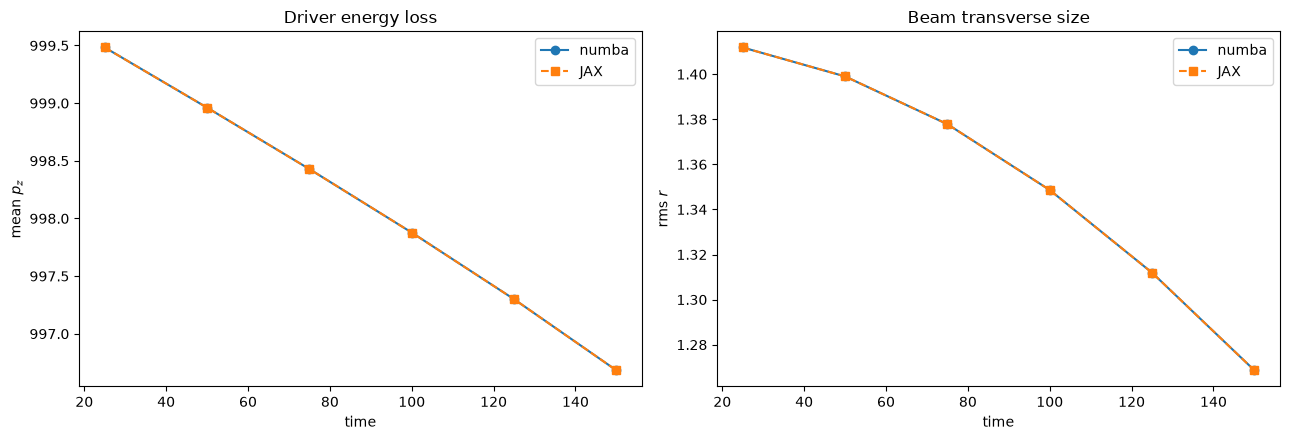

mean p_z  (numba vs JAX): ['999.483/999.483', '998.961/998.961', '998.428/998.428', '997.877/997.877', '997.300/997.300', '996.683/996.683']
max |Δ mean p_z| = 7.67e-07
max |Δ rms r|    = 4.03e-08  (rms r ~ 1.412)


In [4]:
t = np.arange(1, N_STEPS+1) * TIME_STEP
nb_pz  = [float(np.mean(s['p_z'])) for s in nb_steps]
jx_pz  = [float(np.mean(s['p_z'])) for s in jx_steps]
nb_rms = [rms_size(s['r']) for s in nb_steps]
jx_rms = [rms_size(s['r']) for s in jx_steps]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(t, nb_pz, 'o-', label='numba'); ax[0].plot(t, jx_pz, 's--', label='JAX')
ax[0].set_xlabel('time'); ax[0].set_ylabel(r'mean $p_z$'); ax[0].set_title('Driver energy loss'); ax[0].legend()
ax[1].plot(t, nb_rms, 'o-', label='numba'); ax[1].plot(t, jx_rms, 's--', label='JAX')
ax[1].set_xlabel('time'); ax[1].set_ylabel(r'rms $r$'); ax[1].set_title('Beam transverse size'); ax[1].legend()
fig.tight_layout(); plt.show()
print('mean p_z  (numba vs JAX):', [f'{a:.3f}/{b:.3f}' for a,b in zip(nb_pz, jx_pz)])
print(f'max |Δ mean p_z| = {max(abs(a-b) for a,b in zip(nb_pz,jx_pz)):.2e}')
print(f'max |Δ rms r|    = {max(abs(a-b) for a,b in zip(nb_rms,jx_rms)):.2e}  (rms r ~ {nb_rms[0]:.3f})')

## 4. Final beam phase space and the wake

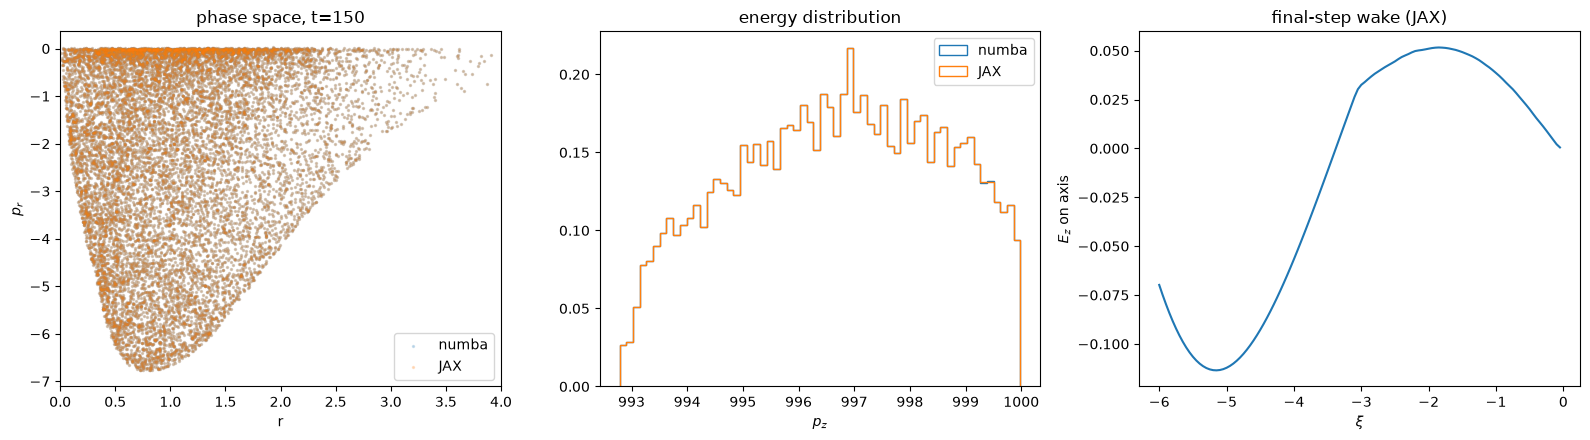

In [5]:
nb_f, jx_f = nb_steps[-1], jx_steps[-1]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(nb_f['r'], nb_f['p_r'], s=2, alpha=0.2, label='numba')
ax[0].scatter(jx_f['r'], jx_f['p_r'], s=2, alpha=0.2, label='JAX')
ax[0].set_xlabel('r'); ax[0].set_ylabel(r'$p_r$'); ax[0].set_xlim(0,4); ax[0].legend(); ax[0].set_title(f'phase space, t={t[-1]:.0f}')
ax[1].hist(nb_f['p_z'], bins=60, histtype='step', label='numba', density=True)
ax[1].hist(jx_f['p_z'], bins=60, histtype='step', label='JAX', density=True)
ax[1].set_xlabel(r'$p_z$'); ax[1].set_title('energy distribution'); ax[1].legend()
xi = np.arange(1, N_XI+1)*XI_STEP
ax[2].plot(-xi, jx_ez); ax[2].set_xlabel(r'$\xi$'); ax[2].set_ylabel(r'$E_z$ on axis'); ax[2].set_title('final-step wake (JAX)')
fig.tight_layout(); plt.show()

## 5. Summary

- Starting from an **identical** driver, the JAX time loop and the original numba code agree
  closely on the coupled, multi-step evolution: the driver's **energy loss** matches to a few
  parts in $10^{-3}$ or better per step, and the **beam size** tracks numba's.
- Residual differences come from the JAX prototype's simplified beam coupling (it omits
  numba's exact per-layer 'fell'-to-next-layer re-processing) — an implementation-phase detail,
  not a physics difference.
- Unlike numba, this run is **fully differentiable**: gradients of any final observable
  (energy, size, spread) w.r.t. the driver's initial parameters flow through the entire
  multi-time-step evolution — see the optimisation notebook.